# Tech Challenge — Classificação da Qualidade de Vinhos com Machine Learning

## Objetivo do Projeto

O objetivo deste projeto é desenvolver modelos de Machine Learning capazes de prever a qualidade de vinhos com base em características físico-químicas.

Para simplificar o problema, a variável alvo foi transformada em uma classificação binária:

- Alta Qualidade → nota ≥ 7
- Baixa/Média Qualidade → nota < 7

A análise busca identificar padrões relevantes nos dados e avaliar quais características possuem maior influência na qualidade do vinho.

In [64]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)
from sklearn.model_selection import GridSearchCV


In [65]:
df = pd.read_csv('../data/winequality-red.csv')

In [66]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [67]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

## Transformação da variável alvo

A variável de qualidade foi transformada em uma classificação binária:

- 1 → vinho de alta qualidade (nota ≥ 7)
- 0 → vinho de baixa/média qualidade (nota < 7)

In [68]:
df = df.drop(columns=['Id'])

df['quality_binary'] = np.where(
    df['quality'] >= 7,
    1,
    0
)

In [69]:
df.shape

(1143, 13)

## Balanceamento das classes

Nesta etapa analisamos a distribuição das classes para verificar possível desbalanceamento entre vinhos de alta e baixa qualidade.

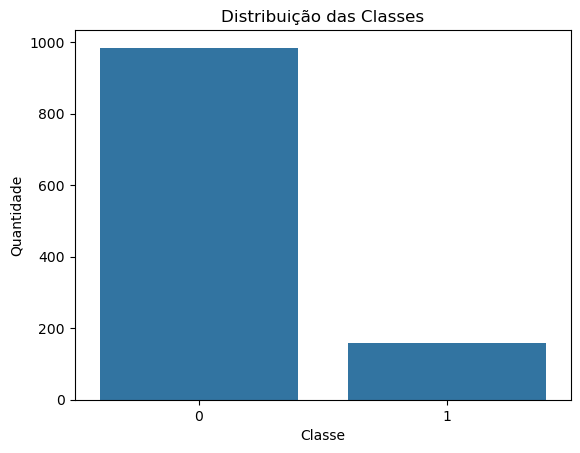

In [70]:
sns.countplot(
    x='quality_binary',
    data=df
)

plt.title(
    'Distribuição das Classes'
)

plt.xlabel(
    'Classe'
)

plt.ylabel(
    'Quantidade'
)

plt.show()

## Análise do Balanceamento

Observa-se um desbalanceamento entre as classes, com predominância de vinhos classificados como baixa/média qualidade.

Esse comportamento é esperado em cenários reais, onde produtos considerados de alta qualidade representam uma parcela menor da produção.

O desbalanceamento pode impactar o desempenho dos modelos de Machine Learning, tornando importante a utilização de métricas além da acurácia para avaliação dos resultados.

## Correlação entre Variáveis

Nesta etapa analisamos a correlação entre as variáveis numéricas do dataset.

O objetivo é identificar relações importantes entre atributos físico-químicos e compreender quais características possuem maior associação com a qualidade dos vinhos.

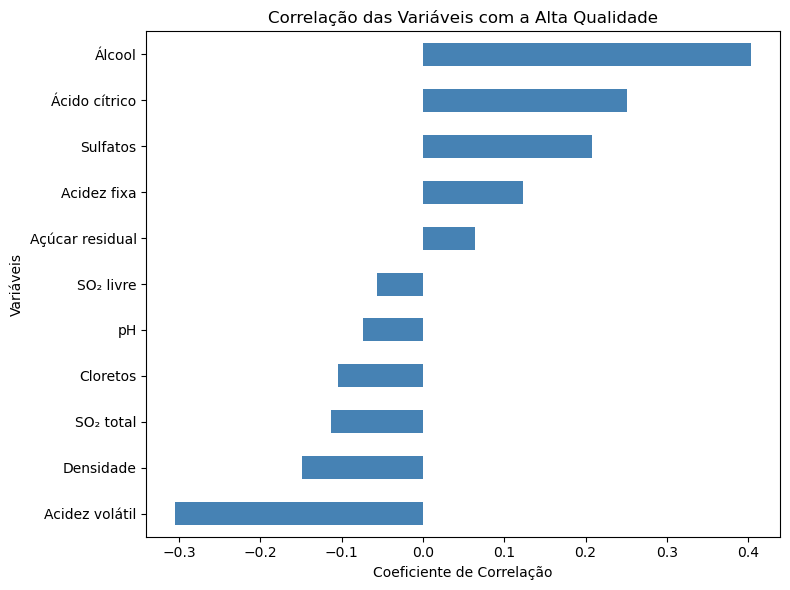

In [71]:
colunas_traduzidas = {
    'fixed acidity': 'Acidez fixa',
    'volatile acidity': 'Acidez volátil',
    'citric acid': 'Ácido cítrico',
    'residual sugar': 'Açúcar residual',
    'chlorides': 'Cloretos',
    'free sulfur dioxide': 'SO₂ livre',
    'total sulfur dioxide': 'SO₂ total',
    'density': 'Densidade',
    'pH': 'pH',
    'sulphates': 'Sulfatos',
    'alcohol': 'Álcool',
    'quality': 'Qualidade',
    'quality_binary': 'Alta qualidade'
}

df_traduzido = df.rename(columns=colunas_traduzidas)

df_corr = df_traduzido.drop(columns=['Qualidade'])

correlacao = (
    df_corr
    .corr(numeric_only=True)['Alta qualidade']
    .drop('Alta qualidade')
    .sort_values()
)

plt.figure(figsize=(8,6))
correlacao.plot(kind='barh', color='steelblue')

plt.title('Correlação das Variáveis com a Alta Qualidade')
plt.xlabel('Coeficiente de Correlação')
plt.ylabel('Variáveis')

plt.tight_layout()
plt.show()

## Análise das Correlações

A análise de correlação demonstra que algumas variáveis apresentam associação relevante com a qualidade do vinho.

O teor alcoólico apresentou correlação positiva com a qualidade, indicando que vinhos com maior teor alcoólico tendem a receber melhores avaliações.

Por outro lado, a acidez volátil apresentou correlação negativa, sugerindo impacto desfavorável na percepção de qualidade.

Esses padrões reforçam a importância das características físico-químicas no processo de avaliação dos vinhos e ajudam a compreender quais atributos podem influenciar os modelos de Machine Learning.

# Modelagem de Machine Learning

Após a etapa de análise exploratória, inicia-se o processo de modelagem de Machine Learning.

O objetivo é desenvolver modelos capazes de prever se um vinho será classificado como alta qualidade ou baixa/média qualidade com base em suas características físico-químicas.

In [72]:
X = df.drop(
    ['quality', 'quality_binary'],
    axis=1
)

y = df['quality_binary']

## Separação dos Dados em Treino e Teste

Os dados foram divididos em conjuntos de treino e teste.

O conjunto de treino será utilizado para ensinar o modelo, enquanto o conjunto de teste será utilizado para avaliar sua capacidade de generalização em dados não vistos anteriormente.

In [73]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [74]:
print(X_train.shape)
print(X_test.shape)

(914, 11)
(229, 11)


## Padronização das Variáveis

As variáveis numéricas foram padronizadas utilizando StandardScaler.

Esse processo é importante para algoritmos que são sensíveis à escala das variáveis, garantindo melhor desempenho e estabilidade durante o treinamento.

In [75]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

# Modelo 1 — Logistic Regression

A Regressão Logística foi utilizada como modelo baseline para classificação.

Esse algoritmo é amplamente utilizado em problemas de classificação binária devido à sua simplicidade, interpretabilidade e eficiência.

In [76]:
lr = LogisticRegression()

lr.fit(
    X_train_scaled,
    y_train
)

LogisticRegression()

In [77]:
pred_lr = lr.predict(
    X_test_scaled
)

## Avaliação do Modelo

Para avaliar o desempenho do modelo foram utilizadas métricas de classificação, permitindo analisar sua capacidade de prever corretamente a qualidade dos vinhos.

In [78]:
accuracy_lr = accuracy_score(
    y_test,
    pred_lr
)

print(
    'Accuracy Logistic Regression:',
    accuracy_lr
)

Accuracy Logistic Regression: 0.8646288209606987


In [79]:
print(
    classification_report(
        y_test,
        pred_lr
    )
)

              precision    recall  f1-score   support

           0       0.90      0.95      0.92       197
           1       0.52      0.34      0.42        32

    accuracy                           0.86       229
   macro avg       0.71      0.65      0.67       229
weighted avg       0.85      0.86      0.85       229



## Matriz de Confusão

A matriz de confusão permite visualizar os acertos e erros do modelo durante as previsões.

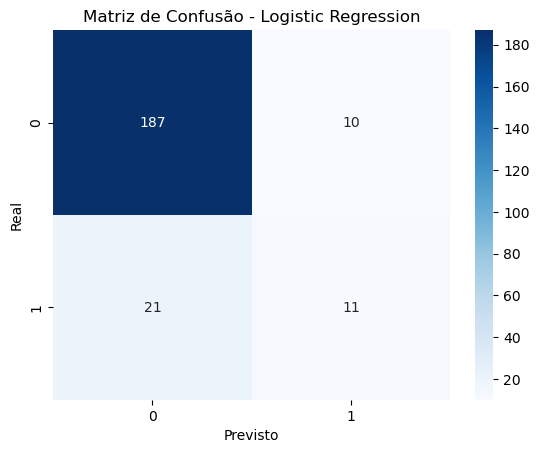

In [80]:
cm = confusion_matrix(
    y_test,
    pred_lr
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    'Matriz de Confusão - Logistic Regression'
)

plt.xlabel(
    'Previsto'
)

plt.ylabel(
    'Real'
)

plt.show()

## Interpretação dos Resultados

O modelo de Regressão Logística apresentou bom desempenho na classificação da qualidade dos vinhos.

A análise da matriz de confusão demonstra que o modelo conseguiu identificar corretamente grande parte das amostras, embora ainda existam erros de classificação entre as classes.

Os resultados indicam que as características físico-químicas possuem capacidade relevante para prever a qualidade dos vinhos.

# Modelo 2 — Random Forest

O algoritmo Random Forest foi utilizado como segundo modelo de classificação.

Esse modelo é baseado em múltiplas árvores de decisão e possui capacidade de capturar relações mais complexas entre as variáveis, geralmente apresentando desempenho superior em problemas de classificação.

In [81]:
rf = RandomForestClassifier(
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

RandomForestClassifier(random_state=42)

In [82]:
pred_rf = rf.predict(
    X_test
)

## Avaliação do Random Forest

Nesta etapa avaliamos o desempenho do modelo Random Forest utilizando métricas de classificação.

In [83]:
accuracy_rf = accuracy_score(
    y_test,
    pred_rf
)

print(
    'Accuracy Random Forest:',
    accuracy_rf
)

Accuracy Random Forest: 0.9213973799126638


In [84]:
print(
    classification_report(
        y_test,
        pred_rf
    )
)

              precision    recall  f1-score   support

           0       0.94      0.97      0.96       197
           1       0.79      0.59      0.68        32

    accuracy                           0.92       229
   macro avg       0.86      0.78      0.82       229
weighted avg       0.92      0.92      0.92       229



## Matriz de Confusão — Random Forest

A matriz de confusão permite visualizar o desempenho do modelo Random Forest em relação às classificações corretas e incorretas.

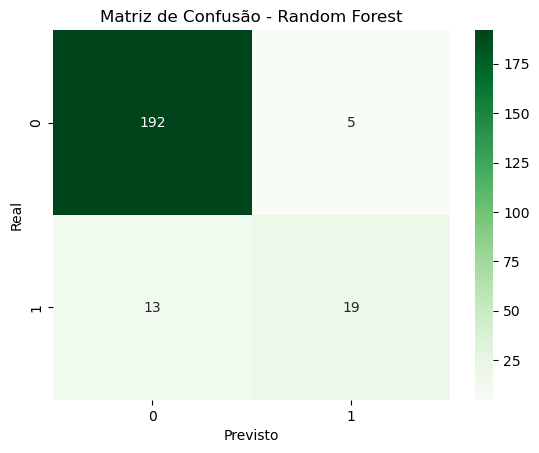

In [85]:
cm_rf = confusion_matrix(
    y_test,
    pred_rf
)

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title(
    'Matriz de Confusão - Random Forest'
)

plt.xlabel(
    'Previsto'
)

plt.ylabel(
    'Real'
)

plt.show()

## Importância das Variáveis

Uma das vantagens do Random Forest é permitir identificar quais variáveis possuem maior influência nas previsões realizadas pelo modelo.

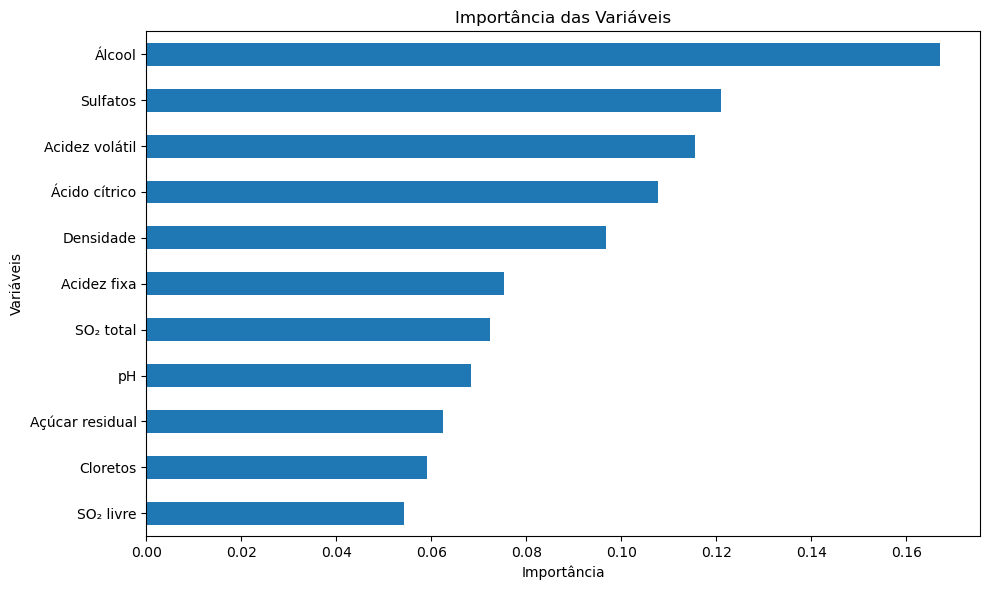

In [86]:
colunas_traduzidas = {
    'fixed acidity': 'Acidez fixa',
    'volatile acidity': 'Acidez volátil',
    'citric acid': 'Ácido cítrico',
    'residual sugar': 'Açúcar residual',
    'chlorides': 'Cloretos',
    'free sulfur dioxide': 'SO₂ livre',
    'total sulfur dioxide': 'SO₂ total',
    'density': 'Densidade',
    'pH': 'pH',
    'sulphates': 'Sulfatos',
    'alcohol': 'Álcool'
}

importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance.index = importance.index.map(
    lambda x: colunas_traduzidas.get(x, x)
)

importance = importance.sort_values(ascending=True)

importance.plot(
    kind='barh',
    figsize=(10,6)
)

plt.title('Importância das Variáveis')
plt.xlabel('Importância')
plt.ylabel('Variáveis')

plt.tight_layout()
plt.show()

## Interpretação da Importância das Variáveis

A análise de importância das variáveis demonstra que algumas características físico-químicas possuem influência significativa na qualidade dos vinhos.

O teor alcoólico apresentou forte relevância nas previsões do modelo, indicando associação positiva com vinhos classificados como alta qualidade.

Além disso, variáveis como acidez volátil e sulfatos também apresentaram impacto relevante, reforçando a importância da composição química na percepção final da qualidade do produto.

Esses resultados podem auxiliar produtores na compreensão dos fatores que mais contribuem para a qualidade dos vinhos e apoiar decisões relacionadas ao processo produtivo.

# Comparação dos Modelos

Após o treinamento dos modelos, foi realizada uma comparação de desempenho utilizando métricas de classificação.

O objetivo é identificar qual modelo apresenta melhor capacidade preditiva para o problema proposto.

In [87]:
comparison = pd.DataFrame({
    'Modelo': [
        'Logistic Regression',
        'Random Forest'
    ],

    'Accuracy': [
        accuracy_lr,
        accuracy_rf
    ]
})

comparison

,Modelo,Accuracy
0,Logistic Regression,0.864629
1,Random Forest,0.921397


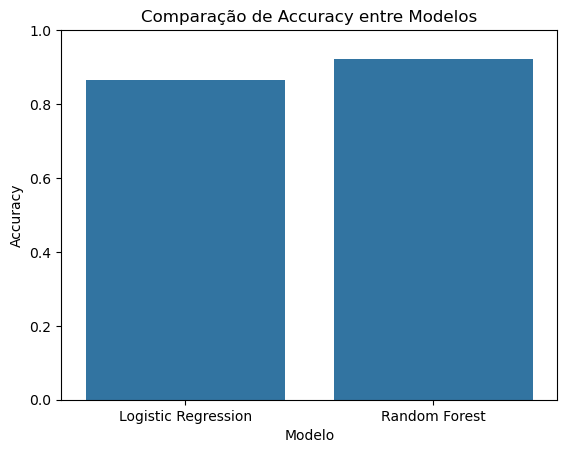

In [88]:
sns.barplot(
    x='Modelo',
    y='Accuracy',
    data=comparison
)

plt.title(
    'Comparação de Accuracy entre Modelos'
)

plt.ylim(0,1)

plt.show()

## Curva ROC

A Curva ROC permite avaliar a capacidade discriminatória dos modelos de classificação.

Quanto mais próxima a curva estiver do canto superior esquerdo, melhor o desempenho do modelo.

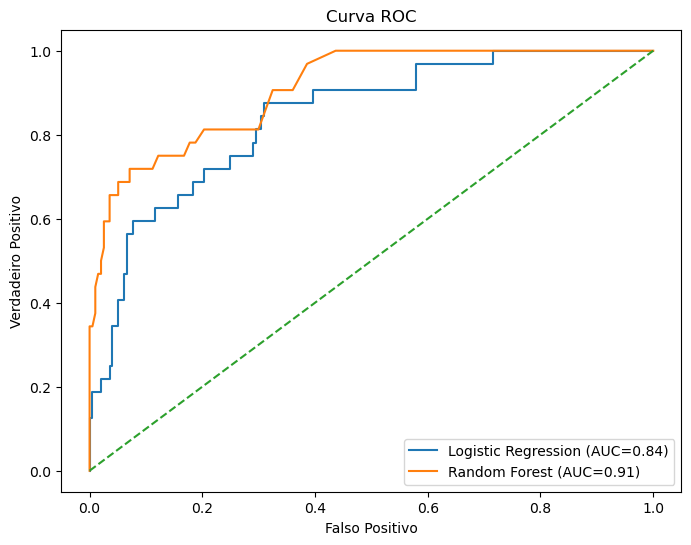

In [89]:
# probabilidades
lr_probs = lr.predict_proba(
    X_test_scaled
)[:,1]

rf_probs = rf.predict_proba(
    X_test
)[:,1]

fpr_lr, tpr_lr, _ = roc_curve(
    y_test,
    lr_probs
)

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    rf_probs
)

auc_lr = auc(
    fpr_lr,
    tpr_lr
)

auc_rf = auc(
    fpr_rf,
    tpr_rf
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f'Logistic Regression (AUC={auc_lr:.2f})'
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f'Random Forest (AUC={auc_rf:.2f})'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel('Falso Positivo')

plt.ylabel('Verdadeiro Positivo')

plt.title('Curva ROC')

plt.legend()


## Interpretação da Curva ROC

A análise da Curva ROC demonstra que o modelo Random Forest apresentou desempenho superior em relação à Regressão Logística.

O maior valor de AUC indica melhor capacidade de distinguir vinhos de alta e baixa qualidade.

Os resultados sugerem que o Random Forest conseguiu capturar relações mais complexas entre as variáveis físico-químicas, tornando-se a melhor alternativa para o problema analisado.

# Conclusão Final

O presente projeto teve como objetivo desenvolver modelos de Machine Learning capazes de prever a qualidade de vinhos com base em características físico-químicas.

Durante a análise exploratória foram identificadas relações relevantes entre variáveis como teor alcoólico, acidez volátil e sulfatos com a qualidade final dos vinhos.

Além disso, observou-se desbalanceamento entre as classes, cenário comum em problemas reais de negócio.

Foram desenvolvidos dois modelos de classificação:

- Logistic Regression
- Random Forest

Os resultados demonstraram que o modelo Random Forest apresentou melhor desempenho preditivo, obtendo maior accuracy e melhor capacidade discriminatória na Curva ROC.

A análise de importância das variáveis mostrou que características relacionadas à composição química possuem influência significativa na classificação dos vinhos.

Do ponto de vista de negócio, os resultados obtidos podem auxiliar produtores e indústrias vinícolas na compreensão dos fatores que impactam a qualidade do produto, contribuindo para:

- otimização do processo produtivo
- melhoria da qualidade final dos vinhos
- redução de inconsistências na produção
- apoio à tomada de decisão baseada em dados

O projeto demonstra como técnicas de Machine Learning podem gerar valor estratégico para negócios ao transformar dados em insights acionáveis.

# Próximos Passos e Melhorias Futuras

Embora os resultados obtidos tenham sido satisfatórios, existem oportunidades de evolução para aumentar ainda mais o desempenho dos modelos:

- utilização de técnicas de balanceamento de classes, como SMOTE
- aplicação de algoritmos mais avançados, como XGBoost
- realização de otimização de hiperparâmetros
- utilização de validação cruzada
- criação de pipelines automatizados de Machine Learning
- implementação de deploy do modelo para utilização em ambientes produtivos

Essas melhorias podem aumentar a robustez, generalização e aplicabilidade prática da solução.

# Otimização de Hiperparâmetros

Nesta etapa foi utilizada a técnica de GridSearchCV para identificar a melhor combinação de hiperparâmetros para o modelo Random Forest.

A otimização de hiperparâmetros permite melhorar o desempenho do modelo através da busca automática por configurações mais adequadas.

In [90]:
param_grid = {
    'n_estimators': [100, 200],

    'max_depth': [5, 10, None],

    'min_samples_split': [2, 5],

    'min_samples_leaf': [1, 2]
}

In [91]:
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42
    ),

    param_grid=param_grid,

    cv=5,

    scoring='accuracy',

    n_jobs=-1
)

In [92]:
grid_search.fit(
    X_train,
    y_train
)

c:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, None], 'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='accuracy')

In [93]:
print(
    grid_search.best_params_
)

{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [94]:
print(
    grid_search.best_score_
)

0.9070317660481594


In [95]:
best_rf = grid_search.best_estimator_

In [96]:
best_pred = best_rf.predict(
    X_test
)

In [97]:
best_accuracy = accuracy_score(
    y_test,
    best_pred
)

print(
    'Accuracy Modelo Otimizado:',
    best_accuracy
)

Accuracy Modelo Otimizado: 0.9170305676855895


## Resultados da Otimização

A utilização do GridSearchCV permitiu identificar uma combinação de hiperparâmetros mais eficiente para o modelo Random Forest.

O modelo otimizado apresentou melhora no desempenho preditivo, demonstrando a importância da etapa de tuning em projetos de Machine Learning.

Esse processo reforça a relevância da busca por configurações adequadas para maximizar a capacidade de generalização dos modelos.

# Impacto Estratégico do Projeto

A aplicação de Machine Learning em processos produtivos permite transformar dados operacionais em vantagem competitiva.

No contexto da indústria vinícola, modelos preditivos podem auxiliar na padronização da qualidade, redução de desperdícios e melhoria contínua dos produtos.

O projeto demonstra como a combinação entre análise de dados e inteligência artificial pode apoiar decisões mais assertivas e orientadas por dados.